# Portfolio Optimization using Markowitz & Black-Litterman Model

#### Mathematical symbols used in this notebook

| Python symbol | Math Symbol | Comment
| -- | -- | --
| rf | $r$ | risk free rate
| lambdaa | $\lambda$ | risk aversion coefficient
| C | $C$ | Assets covariance matrix
| V | $V$ | Assets variances (diagonal in covariance matrix)
| W | $W$ | Assets weights
| R | $R$ | Assets returns
| mean | $\mu$ | Portfolio historical return
| var | $\sigma$ | Portfolio historical variance
| Pi | $\Pi$ | Portfolio equilibrium excess returns
| tau | $\tau$ | Scaling factor for Black-litterman

## Importing all the necessary libraries

In [41]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib_inline
import seaborn as sns

import scipy.optimize
import yfinance as yf

from collections import defaultdict
from IPython.display import HTML

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (16, 9)

## Load Historical Prices

In [42]:
# Load NIFTY 50 constituents
nifty50 = pd.read_csv("ind_nifty50list.csv")

# Convert NSE symbols to Yahoo Finance tickers
stocks_list = (
    nifty50["Symbol"]
    .str.strip()
    .replace({"TATAMOTORS": "TMPV"})
    .apply(lambda x: f"{x}.NS")
    .tolist()
)

print(f"Number of stocks: {len(stocks_list)}")
print(stocks_list[:10])

Number of stocks: 50
['ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS', 'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BEL.NS', 'BHARTIARTL.NS']


In [43]:
# Fetch market capitalizations
market_cap = {}
failed_tickers = []

for ticker in stocks_list:
    try:
        info = yf.Ticker(ticker).info
        market_cap[ticker] = info.get("marketCap")

        if market_cap[ticker] is None:
            failed_tickers.append(ticker)

    except Exception:
        failed_tickers.append(ticker)

print(f"Successfully retrieved market caps for {len(market_cap) - len(failed_tickers)} stocks.")

if failed_tickers:
    print("Failed tickers:", failed_tickers)

Successfully retrieved market caps for 50 stocks.


In [44]:
# Download historical adjusted closing prices for all NIFTY 50 stocks
def load_data():

    price_data = yf.download(
        stocks_list,
        period="10y",
        interval="1d",
        auto_adjust=True,
        progress=False
    )["Close"]

    # Convert to DataFrame if only one ticker is returned
    if isinstance(price_data, pd.Series):
        price_data = price_data.to_frame()

    # Keep only the most recent 2000 trading days
    price_data = price_data.tail(2000)

    # Fill any missing observations
    price_data = price_data.ffill().bfill()

    symbols = price_data.columns.tolist()

    prices_out = [price_data[col].values for col in symbols]
    caps_out = [market_cap[s] for s in symbols]

    return symbols, prices_out, caps_out


names, prices, caps = load_data()
prices = np.array(prices)

In [45]:
# Calculate annualized expected returns and covariance matrix
def daily_asset_estimator(prices):

    prices = np.asarray(prices)

    # Daily simple returns
    historical_returns = prices[:, 1:] / prices[:, :-1] - 1

    # Annualized expected returns
    expected_returns = (1 + historical_returns.mean(axis=1)) ** 252 - 1

    # Annualized covariance matrix
    covariance = np.cov(historical_returns) * 252

    return expected_returns, covariance


# Market-cap weights
W = np.array(caps, dtype=float)
W = W / W.sum()

# Historical estimates
R, C = daily_asset_estimator(prices)

# Risk-free rate (India)
rf = 0.065

In [46]:
summary = pd.DataFrame({
    "Expected Annual Return": R,
    "Market Cap Weight": W
}, index=names)

summary["Expected Annual Return"] = summary["Expected Annual Return"].map(lambda x: f"{x:.2%}")
summary["Market Cap Weight"] = summary["Market Cap Weight"].map(lambda x: f"{x:.2%}")

display(summary.T)

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Expected Annual Return,82.46%,31.78%,39.91%,14.33%,18.41%,25.20%,22.11%,30.92%,47.91%,30.39%,...,24.47%,25.83%,27.68%,8.14%,18.34%,27.76%,14.18%,44.83%,20.31%,13.03%
Market Cap Weight,2.25%,2.21%,0.65%,1.34%,2.13%,1.40%,1.55%,3.28%,1.56%,6.09%,...,2.33%,0.56%,1.21%,3.87%,0.64%,2.02%,0.65%,0.91%,1.76%,0.89%


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
ADANIENT.NS,0.2591,0.1251,0.0352,0.0340,0.0522,0.0338,0.0605,0.0652,0.0599,0.0368,...,0.0321,0.0402,0.0601,0.0258,0.0320,0.0379,0.0781,0.0529,0.0493,0.0312
ADANIPORTS.NS,0.1251,0.1428,0.0270,0.0281,0.0477,0.0290,0.0487,0.0520,0.0546,0.0320,...,0.0258,0.0350,0.0526,0.0199,0.0290,0.0339,0.0583,0.0396,0.0428,0.0243
APOLLOHOSP.NS,0.0352,0.0270,0.1026,0.0193,0.0252,0.0209,0.0320,0.0352,0.0312,0.0179,...,0.0231,0.0269,0.0280,0.0148,0.0236,0.0223,0.0304,0.0265,0.0271,0.0214
ASIANPAINT.NS,0.0340,0.0281,0.0193,0.0624,0.0249,0.0196,0.0307,0.0322,0.0187,0.0177,...,0.0127,0.0257,0.0195,0.0142,0.0171,0.0269,0.0270,0.0277,0.0292,0.0138
AXISBANK.NS,0.0522,0.0477,0.0252,0.0249,0.1082,0.0306,0.0581,0.0603,0.0417,0.0291,...,0.0180,0.0312,0.0465,0.0189,0.0253,0.0349,0.0557,0.0401,0.0393,0.0216
BAJAJ-AUTO.NS,0.0338,0.0290,0.0209,0.0196,0.0306,0.0702,0.0309,0.0317,0.0220,0.0228,...,0.0170,0.0221,0.0288,0.0137,0.0157,0.0269,0.0425,0.0291,0.0255,0.0174
BAJAJFINSV.NS,0.0605,0.0487,0.0320,0.0307,0.0581,0.0309,0.1089,0.0968,0.0411,0.0317,...,0.0207,0.0362,0.0502,0.0202,0.0290,0.0387,0.0557,0.0461,0.0422,0.0239
BAJFINANCE.NS,0.0652,0.0520,0.0352,0.0322,0.0603,0.0317,0.0968,0.1295,0.0424,0.0329,...,0.0203,0.0379,0.0502,0.0195,0.0289,0.0401,0.0589,0.0524,0.0432,0.0237
BEL.NS,0.0599,0.0546,0.0312,0.0187,0.0417,0.0220,0.0411,0.0424,0.1413,0.0246,...,0.0210,0.0296,0.0520,0.0150,0.0248,0.0311,0.0584,0.0379,0.0353,0.0190
BHARTIARTL.NS,0.0368,0.0320,0.0179,0.0177,0.0291,0.0228,0.0317,0.0329,0.0246,0.0832,...,0.0188,0.0239,0.0315,0.0142,0.0187,0.0220,0.0347,0.0244,0.0267,0.0150


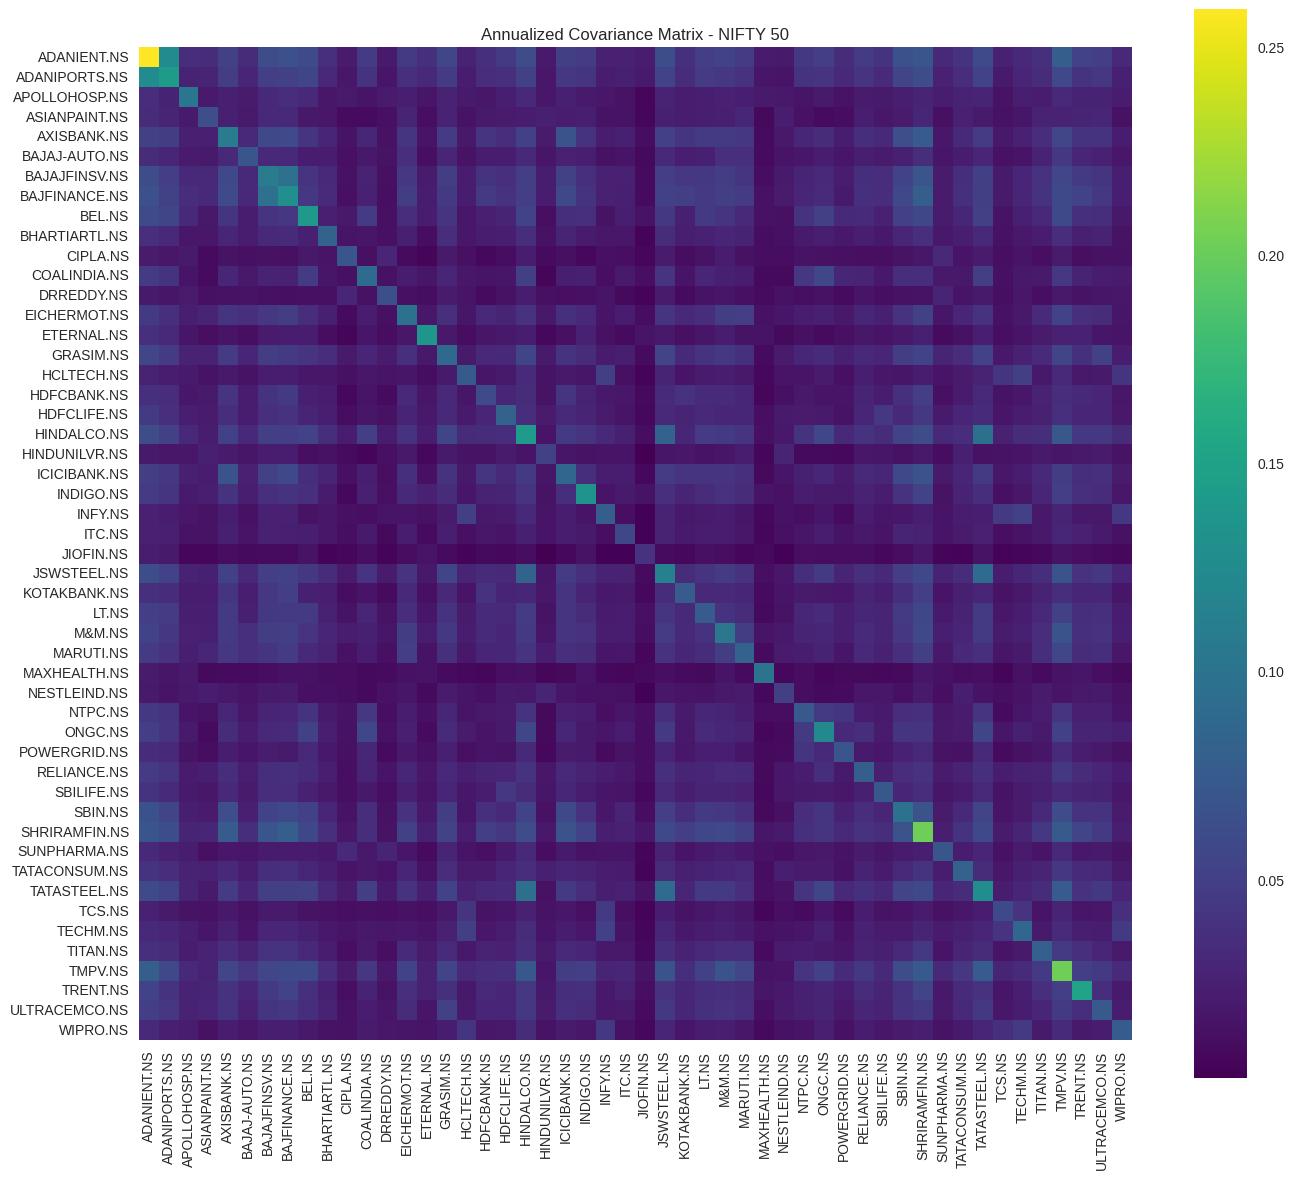

In [47]:
cov_matrix = pd.DataFrame(C, index=names, columns=names)

display(cov_matrix.round(4))

plt.figure(figsize=(14, 12))
sns.heatmap(cov_matrix, cmap="viridis", square=True)
plt.title("Annualized Covariance Matrix - NIFTY 50")
plt.tight_layout()
plt.show()

In [48]:
# #plotting covariance
# df = pd.DataFrame(C, columns = names, index = names)
# colormap = sns.color_palette("coolwarm")
# ax = sns.heatmap(df, cmap = colormap, annot = True, linewidths = 0.5, linecolor = 'white', cbar = True)
# plt.show()

In [50]:
# Compute correlation matrix from covariance matrix
def correlation_from_covariance(covariance):
    std_dev = np.sqrt(np.diag(covariance))
    correlation = covariance / np.outer(std_dev, std_dev)

    # Numerical stability
    correlation = np.clip(correlation, -1, 1)

    return correlation


correlation = pd.DataFrame(
    correlation_from_covariance(C),
    index=names,
    columns=names
)

# Display only the lower triangle
mask = np.triu(np.ones_like(correlation, dtype=bool))
correlation = correlation.mask(mask)

display(
    correlation.style
    .background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1)
    .highlight_null(color="#f1f1f1")
    .format("{:.2f}")
)

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,COALINDIA.NS,DRREDDY.NS,EICHERMOT.NS,ETERNAL.NS,GRASIM.NS,HCLTECH.NS,HDFCBANK.NS,HDFCLIFE.NS,HINDALCO.NS,HINDUNILVR.NS,ICICIBANK.NS,INDIGO.NS,INFY.NS,ITC.NS,JIOFIN.NS,JSWSTEEL.NS,KOTAKBANK.NS,LT.NS,M&M.NS,MARUTI.NS,MAXHEALTH.NS,NESTLEIND.NS,NTPC.NS,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBILIFE.NS,SBIN.NS,SHRIRAMFIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
ADANIENT.NS,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
ADANIPORTS.NS,0.65,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
APOLLOHOSP.NS,0.22,0.22,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
ASIANPAINT.NS,0.27,0.30,0.24,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
AXISBANK.NS,0.31,0.38,0.24,0.30,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BAJAJ-AUTO.NS,0.25,0.29,0.25,0.30,0.35,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BAJAJFINSV.NS,0.36,0.39,0.30,0.37,0.54,0.35,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BAJFINANCE.NS,0.36,0.38,0.31,0.36,0.51,0.33,0.82,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BEL.NS,0.31,0.38,0.26,0.20,0.34,0.22,0.33,0.31,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BHARTIARTL.NS,0.25,0.29,0.19,0.25,0.31,0.30,0.33,0.32,0.23,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


## Helper functions for Optimization

In [51]:
# Portfolio expected return
def port_mean(expected_returns, weights):
    return np.dot(expected_returns, weights)


# Portfolio variance
def port_var(weights, covariance):
    return weights @ covariance @ weights

In [52]:
# Optimize weights
def optimize_weights(R, C, rf):
    # Utility function to solve weights which we have to optimize
    def util_function(W, R, C, rf):
        mean = port_mean(R, W)
        var = port_var(W, C)
        util = (mean - rf) / np.sqrt(var) # Sharpe ratio
        return 1/util # To Maximize the sharpe ratio

    n = len(R)
    W = np.ones(n)/n # initialize weights with equal values
    bound = [(0., 1.) for i in range(n)]  # defining bounds for weights
    constraint = [{'type': 'eq', 'fun': lambda W: np.sum(W) - 1.}] # constraint for weights

    optimized_weights = scipy.optimize.minimize(util_function, W, (R, C, rf), method = 'SLSQP', constraints = constraint, bounds = bound)
    if not optimized_weights.success:
        raise BaseException(optimized_weights.message)
    return optimized_weights.x

In [53]:
# For different returns we will find optimal weights and mean, variance which will help in plotting graph
def optimize_frontier(R, C, rf):
    # utility function for a particular return
    def util_function(W, R, C, r):
        mean = port_mean(R, W)
        var = port_var(W, C)
        penalty = 100 * abs(mean - r)
        return var + penalty

    frontier_means = []
    frontier_vars = []
    frontier_weights = []
    n = len(R)

    for r in np.linspace(min(R), max(R), num = 30):
        W = np.ones(n)/n
        bound = [(0, 1) for i in range(n)]  # Defining bounds for weights
        constraint = [{'type': 'eq', 'fun': lambda W: np.sum(W) - 1}] # constraint for weights

        optimize_weights = scipy.optimize.minimize(util_function, W, (R, C, r), method = 'SLSQP', bounds = bound, constraints = constraint)

        if not optimize_weights.success:
            raise BaseException(optimize_weights.message)
        frontier_weights.append(optimize_weights.x)
        frontier_means.append(r)
        frontier_vars.append(port_var(optimize_weights.x, C))

    return np.array(frontier_means), np.array(frontier_vars), np.array(frontier_weights)


In [54]:
class Result:
    def __init__(self, W, tangent_mean, tangent_var, frontier_mean, frontier_var, frontier_weights):
        self.W = W
        self.tangent_mean = tangent_mean
        self.tangent_var = tangent_var
        self.frontier_mean = frontier_mean
        self.frontier_var = frontier_var
        self.frontier_weights = frontier_weights

## Efficient Frontier

In [55]:
# Function to get the Efficient Frontier
def get_frontier(R, C, rf):
    W = optimize_weights(R, C, rf)
    tangent_mean = port_mean(R, W)
    tangent_var = port_var(W, C)
    frontier_means, frontier_vars, frontier_weights = optimize_frontier(R, C, rf)
    return Result(W, tangent_mean, tangent_var, frontier_means, frontier_vars, frontier_weights)

In [56]:
# Display Assets
def display_assets(names, R, C, color = 'black'):
    plt.scatter([C[i, i] ** .5 for i in range(n)], R, marker = 'X', color = color), plt.grid(True)  # draw assets
    for i in range(n):
        plt.text(C[i, i] ** .5, R[i], '%s' % names[i], verticalalignment = 'center', color = color) # draw labels

# Display Efficient Frontier
def display_frontier(result: Result, label = None, color = 'black'):
    plt.text(result.tangent_var ** .5, result.tangent_mean, 'tangent', verticalalignment = 'center', color = color)
    plt.scatter(result.tangent_var ** .5, result.tangent_mean, marker = 'o', color = color), plt.grid(True)
    plt.plot(list(result.frontier_var ** .5), list(result.frontier_mean), label = label, color = color), plt.grid(True) # draw efficient frontier

result_1 = get_frontier(R, C, rf)
n = len(R)

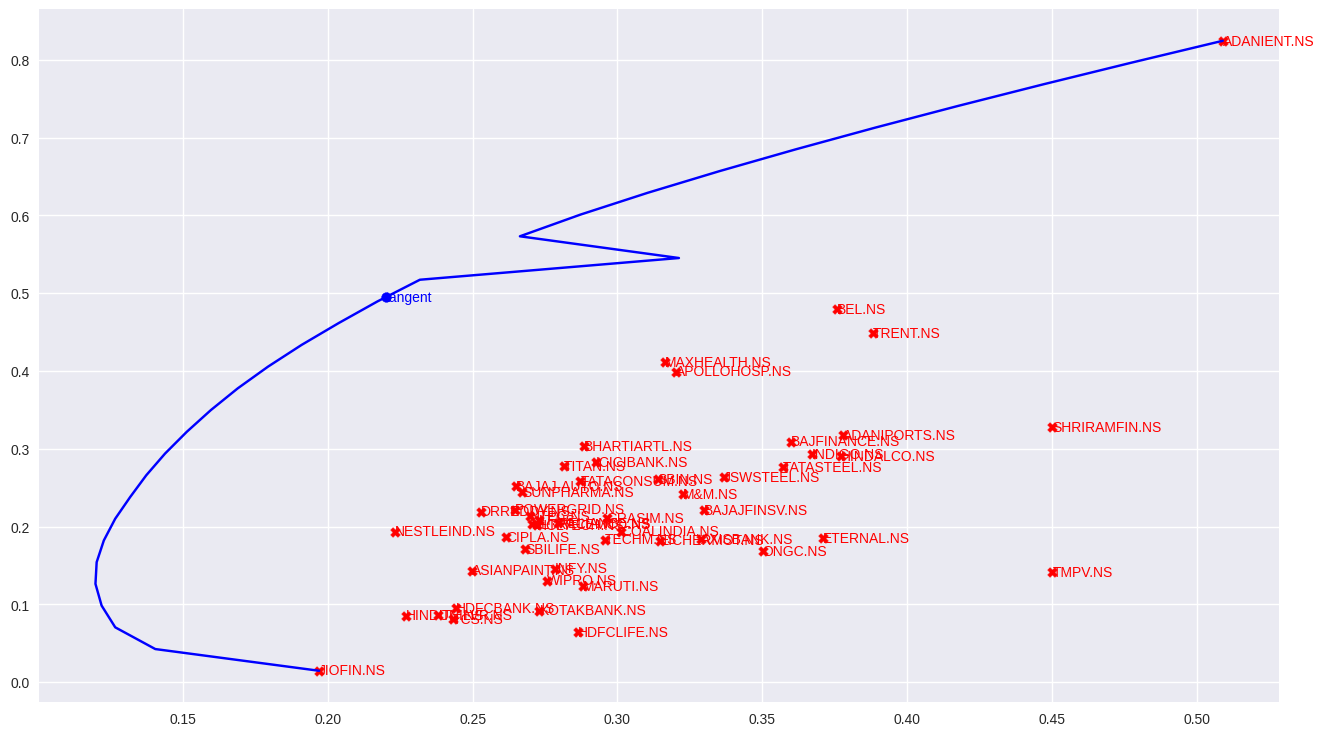

In [58]:
display_assets(names, R, C, color = 'red')
display_frontier(result_1, color = 'blue')

## Markowitz Portfolio Model

In [59]:
# Load NIFTY 50 index data
def load_nifty_data():
    nifty_prices = yf.download(
        "^NSEI",
        period="10y",
        interval="1d",
        auto_adjust=True,
        progress=False
    )["Close"]

    nifty_prices = nifty_prices.squeeze().tail(2000).to_list()

    return nifty_prices


nifty_prices = load_nifty_data()

In [60]:
# Calculate NIFTY 50 market returns
def NIFTY_market_return(nifty_prices):
    # Convert the input index prices into a numpy matrix
    nifty_prices = np.matrix(nifty_prices)
    r, c = nifty_prices.shape

    # Create an empty numpy array to store historical returns
    historical_returns = np.empty([r, c-1])
    for ri in range(r):
        for ci in range(c-1):
            prior_price, after_price = nifty_prices[ri, ci], nifty_prices[ri, ci+1]
            historical_returns[ri, ci] = (after_price/prior_price)-1

    # Calculate the market variance of the historical returns
    market_variance = np.cov(historical_returns)

    # Calculate the annualized market return
    market_return = (1 + np.mean(historical_returns[0])) ** 252 - 1
    print(market_return)

    # Calculate the annualized market variance
    market_variance = market_variance * 252
    print(market_variance)

    # Calculate the volatility of the market
    volatility = np.sqrt(market_variance)
    print(volatility)

    # Return the annualized market return and variance
    return market_return, market_variance


market_return, market_variance = NIFTY_market_return(nifty_prices)

0.1276937023668292
0.02974289433760766
0.17246128359028196


In [61]:
# Calculate Covariance matrix
def calculate_cov_matrix(stock_prices, nifty_prices):
    # Convert prices to numpy matrices
    stock_prices = np.matrix(stock_prices)
    nifty_prices = np.matrix(nifty_prices)

    # Get number of rows and columns in stock_prices
    rows, cols = stock_prices.shape

    # Create empty matrices to store returns
    stock_returns = np.empty([rows, cols - 1])
    nifty_returns = np.empty([rows, cols - 1])

    # Calculate returns
    for r in range(rows):
        for c in range(cols - 1):
            # Calculate stock returns
            p0, p1 = stock_prices[r, c], stock_prices[r, c + 1]
            stock_returns[r, c] = (p1 / p0) - 1

            # Calculate NIFTY returns
            if r == 0:
                p2, p3 = nifty_prices[r, c], nifty_prices[r, c + 1]
                nifty_returns[r, c] = (p3 / p2) - 1

    # Calculate covariance matrix
    cov_matrix = []
    for r in range(rows):
        covar = np.cov(stock_returns[r], nifty_returns)[0, 1]
        cov_matrix.append(covar)

    # Annualize covariance matrix and return as numpy array
    return np.asarray(cov_matrix) * 252

In [62]:
# Covariance of each stock return with market return and calculating Beta
cov_matrix = calculate_cov_matrix(prices, nifty_prices)
beta = cov_matrix / market_variance
print(beta)

[ 0.09857604  0.07583188  0.14058884  0.06011487  0.10427867  0.05456729
  0.22395483  0.21463216  0.16447176  0.04163504 -0.00197713  0.09313896
  0.04069019  0.10331093  0.02451024  0.10288387  0.06460515  0.10387236
  0.09332402  0.10226774  0.00154096  0.18991784 -0.01985507  0.05901052
  0.07059907 -0.01022444  0.10908236  0.06259264  0.10471213  0.20669216
  0.10665179 -0.00539392  0.03594139  0.09383666  0.17384069  0.0312094
  0.14050206  0.01926085  0.15360693  0.15123553  0.08952147  0.06652029
  0.16299016  0.06796127  0.0936836   0.07541217  0.15949787  0.07681391
  0.05113334  0.06992688]


In [63]:
# Caluclating the expected return of each asset using the markowitz formula
def markowitz_portfolio_return(result: Result, C, rf, market_return, market_variance):
    return rf + np.dot(beta, (market_return - rf))

expected_asset_return = markowitz_portfolio_return(result_1, C, rf, market_return, market_variance)
print(expected_asset_return)

[0.0711801  0.06975418 0.07381403 0.06876882 0.07153762 0.06842103
 0.07904056 0.07845608 0.07531134 0.06761025 0.06487605 0.07083923
 0.06755102 0.07147694 0.06653664 0.07145017 0.06905034 0.07151214
 0.07085083 0.07141154 0.06509661 0.07690665 0.06375521 0.06869959
 0.06942612 0.06435899 0.07183878 0.06892416 0.07156479 0.0779583
 0.0716864  0.06466184 0.0672533  0.07088297 0.07589872 0.06695663
 0.07380859 0.06620753 0.07463019 0.07448152 0.07061243 0.0691704
 0.07521846 0.06926074 0.07087337 0.06972787 0.07499951 0.06981575
 0.06820574 0.06938398]


## Black-Litterman Reverse Optimization

Black-Litterman Mathematical formula:
$$E(R) = [(\tau \Sigma)^{-1} + (P^T\Omega^{-1} P)^{-1}][(\tau \Sigma)^{-1}\pi + (P^T\Omega^{-1}Q)]$$

In [64]:
# Calculate portfolio historical return and variance
mean = port_mean(R, W)
var = port_var(W, C)

# Calculate risk aversion
lambdaa = (mean - rf) / var

# Calculate equilibrium excess returns
Pi = np.dot(np.dot(lambdaa, C), W)
print(Pi + rf)

[0.33174314 0.28601448 0.18583684 0.18124893 0.2769937  0.19481659
 0.28042088 0.29593267 0.24890433 0.21054069 0.14104643 0.20101856
 0.14159872 0.23161145 0.16137758 0.25292829 0.18066435 0.22044761
 0.21114992 0.28578526 0.15535224 0.26276227 0.22182706 0.18246121
 0.17213297 0.11521456 0.27532968 0.21986922 0.24146217 0.25425093
 0.23496494 0.12279474 0.15155127 0.19841442 0.22380646 0.17443559
 0.24032492 0.1953896  0.27601771 0.31642731 0.17204275 0.20704264
 0.27712781 0.16998275 0.19400971 0.21462526 0.30534302 0.23926018
 0.23278922 0.18265467]


## Equillibrium Excess return plot

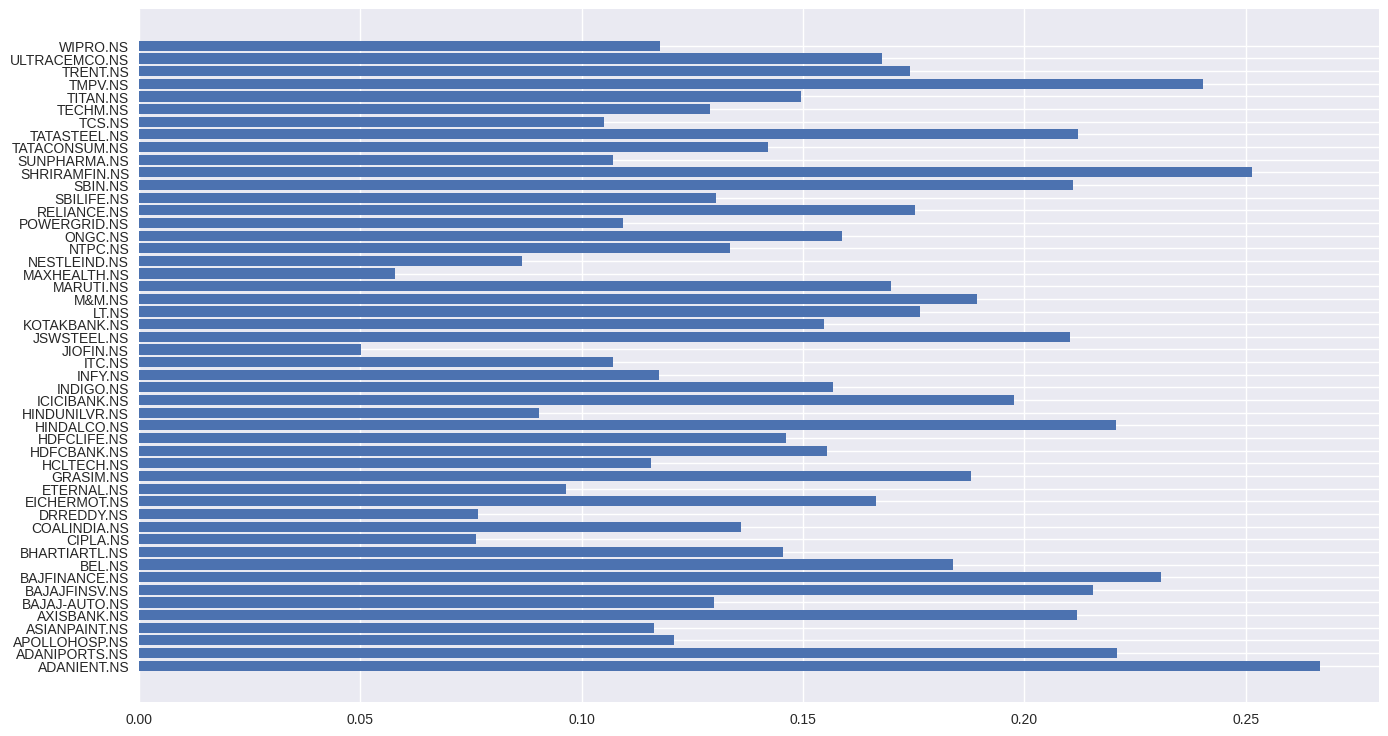

In [66]:
# Equilibrium excess return calculated during Reverse optimization
plt.barh(names, Pi)
plt.show()

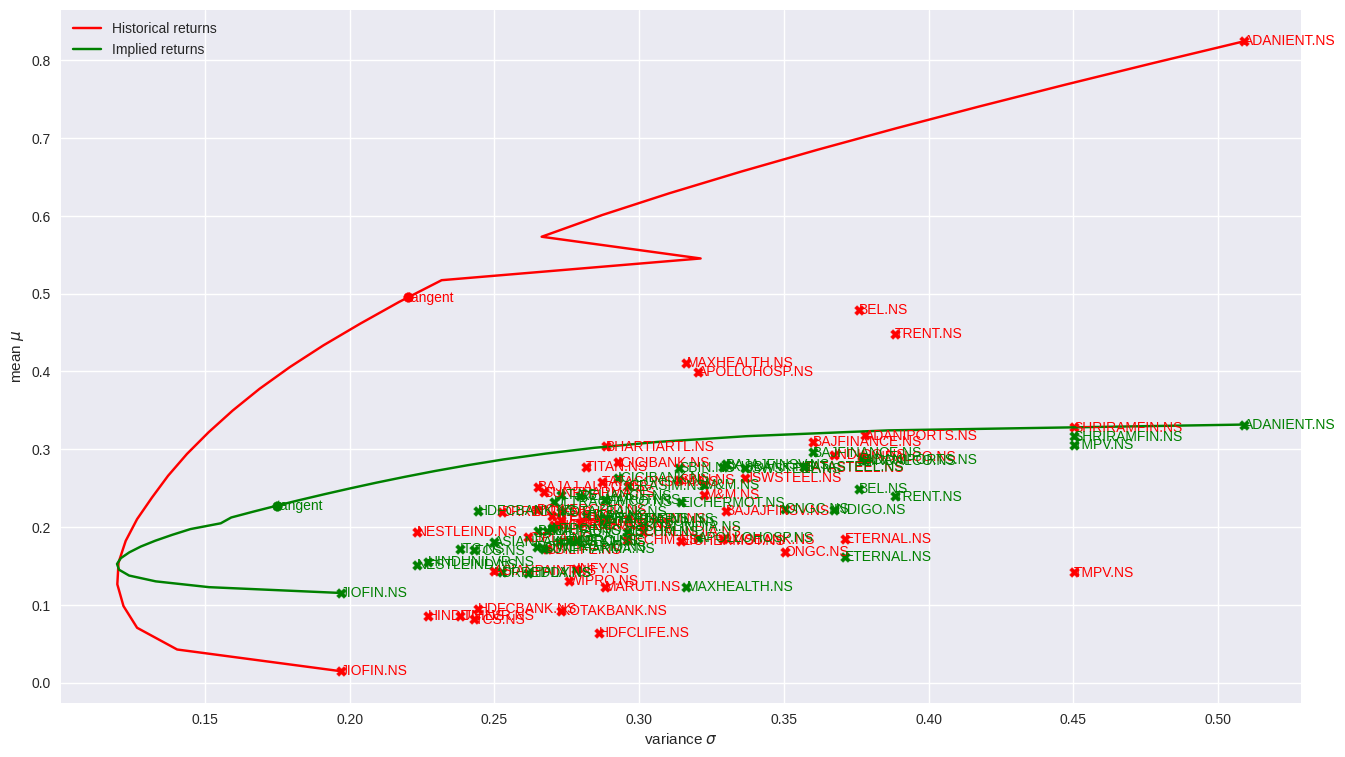

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Weight,0.022495,0.022115,0.00653,0.013367,0.021288,0.014038,0.015589,0.032645,0.015709,0.060945,...,0.023362,0.005635,0.012124,0.038549,0.006291,0.020155,0.006504,0.009114,0.017632,0.008901


In [67]:
# Calculate the Black-Litterman Model optimal weights and plotting the efficient frontier
result_2 = get_frontier(Pi + rf, C, rf)

display_assets(names, R, C, color = 'red')
display_frontier(result_1, label = 'Historical returns', color = 'red')
display_assets(names, Pi + rf, C, color = 'green')
display_frontier(result_2, label = 'Implied returns', color = 'green')
plt.xlabel('variance $\sigma$')
plt.ylabel('mean $\mu$')
plt.legend()
plt.show()
display(pd.DataFrame({'Weight': result_2.W}, index = names).T)

In [68]:
# Markowitz Model weight distribution
display(pd.DataFrame({'Weight': result_1.W}, index = names).T)

# Black-Litterman Model weight distribution
display(pd.DataFrame({'Weight': result_2.W}, index = names).T)

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Weight,0.221998,0.0,0.149917,2.277598e-17,0.0,9.955629e-17,0.0,5.636754e-17,0.130382,0.08225,...,1.585405e-17,3.692968e-18,4.564125e-17,0.0,3.265676e-17,5.381642e-17,3.752715e-17,0.101711,0.0,3.877283e-17


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Weight,0.022495,0.022115,0.00653,0.013367,0.021288,0.014038,0.015589,0.032645,0.015709,0.060945,...,0.023362,0.005635,0.012124,0.038549,0.006291,0.020155,0.006504,0.009114,0.017632,0.008901


## Optimization based on Equilibrium returns with adjusted views

In [71]:
# Function to create the view and link matrix
def create_views_and_link_matrix(names, relative_views, absolute_views_1):
    r, a, c = len(relative_views), len(absolute_views_1), len(names)
    Q = [relative_views[i][3] for i in range(r)]

    if absolute_views_1:
        for i in absolute_views_1:
            Q.append(i[1])

    P = np.zeros([r + a, c])

    nameToIndex = dict()
    for i, n in enumerate(names):
        nameToIndex[n] = i

    for i, v in enumerate(relative_views):
        name1, name2 = relative_views[i][0], relative_views[i][2]
        P[i, nameToIndex[name1]] = +1 if relative_views[i][1] == '>' else -1
        P[i, nameToIndex[name2]] = -1 if relative_views[i][1] == '>' else +1

    for i, v in enumerate(absolute_views_1):
        name = absolute_views_1[i][0]
        P[i + r, nameToIndex[name]] += 1

    return np.array(Q), P


# -----------------------------
# Investor Views (NIFTY 50)
# -----------------------------

relative_views = [
    ('RELIANCE.NS', '>', 'ONGC.NS', 0.020),
    ('HDFCBANK.NS', '>', 'SBIN.NS', 0.015),
    ('TCS.NS', '>', 'WIPRO.NS', 0.010),
    ('ICICIBANK.NS', '>', 'KOTAKBANK.NS', 0.010),
    ('BHARTIARTL.NS', '>', 'ITC.NS', 0.015)
]

absolute_views = [
    ('RELIANCE.NS', 0.18),
    ('HDFCBANK.NS', 0.16),
    ('ICICIBANK.NS', 0.17),
    ('INFY.NS', 0.15),
    ('TCS.NS', 0.14),
    ('BHARTIARTL.NS', 0.18),
    ('LT.NS', 0.17),
    ('SUNPHARMA.NS', 0.16),
    ('TITAN.NS', 0.18),
    ('BAJFINANCE.NS', 0.17)
]

Q, P = create_views_and_link_matrix(names, relative_views, absolute_views)

print("Views Matrix")
display(pd.DataFrame({"Views": Q}))

print("Link Matrix")
P = pd.DataFrame(P)
P.columns = names
display(P)

Views Matrix


,Views
0,0.020
1,0.015
2,0.010
3,0.010
4,0.015
5,0.180
6,0.160
7,0.170
8,0.150
9,0.140


Link Matrix


,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TMPV.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,-1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
# Function for Black-Litterman Model Equation
tau = 0.025  # Scaling Factor

# Calculate Omega - uncertainty matrix about views
omega = np.dot(np.dot(np.dot(tau, P), C), np.transpose(P))  # 0.25 * P * C * transpose(P)

new_omega = np.zeros(omega.shape)
np.fill_diagonal(new_omega, np.diag(omega))

# Calculate Equilibrium excess returns with views incorporated
sub_a = np.linalg.inv(np.dot(tau, C))  # (tau.C)^-1
sub_b = np.dot(np.dot(np.transpose(P), np.linalg.inv(new_omega)), P)  # (P^T.omega^-1).P
sub_c = np.dot(np.linalg.inv(np.dot(tau, C)), Pi)  # ((Tau.C)^-1).Pi
sub_d = np.dot(np.dot(np.transpose(P), np.linalg.inv(new_omega)), Q)   # (P^T.omega^-1).Q

# Expected_return = ((tau.C)^-1 + (P^T.omega^-1).P) * ((Tau.C)^-1).Pi + (P^T.omega^-1).Q)
Pi_adj = np.dot(np.linalg.inv(sub_a + sub_b), (sub_c + sub_d))

# print(omega)

result_3 = get_frontier(Pi_adj + rf, C, rf)

final_weights = result_3.W
excess_weight = 0
for i in range(len(final_weights)):
    if final_weights[i] > 0.10:
        excess_weight += final_weights[i] - 0.1

individual_weights = excess_weight / len(final_weights)

for i in range(len(final_weights)):
    final_weights[i] += individual_weights

final_tan_mean = port_mean(Pi_adj+rf, final_weights)
final_tan_var = port_var(final_weights, C)


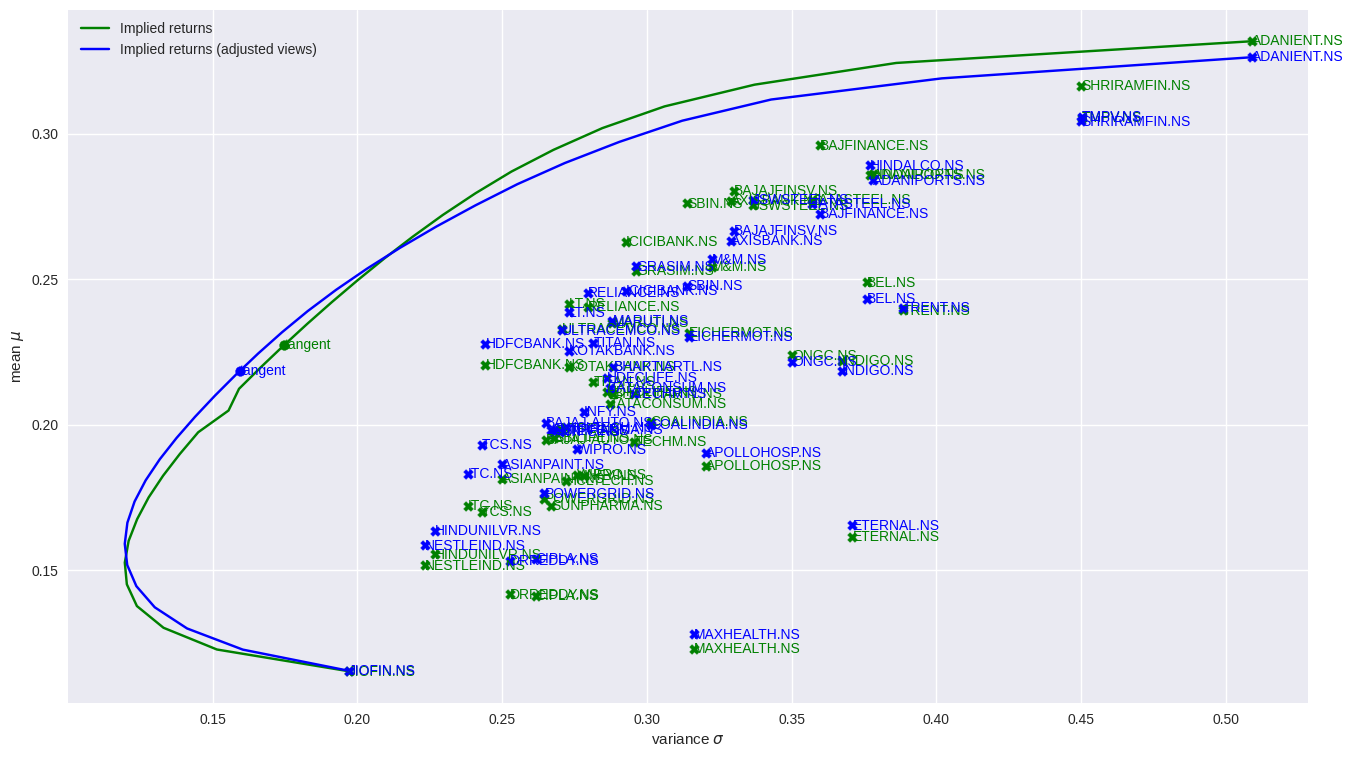

In [73]:
# Calculate the Black-Litterman Model optimal weights with adjusted views and plotting the efficient frontier
display_assets(names, Pi + rf, C, color = 'green')
display_frontier(result_2, label = 'Implied returns', color = 'green')
display_assets(names, Pi_adj + rf, C, color = 'blue')
display_frontier(result_3, label = 'Implied returns (adjusted views)', color = 'blue')

#plt.scatter(np.sqrt(final_tan_var), final_tan_mean, marker='*', color='r' )
plt.xlabel('variance $\sigma$')
plt.ylabel('mean $\mu$')
plt.legend()
plt.show()

In [75]:
display(
    pd.DataFrame(
        {
            'Black-Litterman Weights': result_2.W,
            'Black-Litterman (Adjusted Views)': final_weights
        },
        index=names
    )
)

,Black-Litterman Weights,Black-Litterman (Adjusted Views)
ADANIENT.NS,0.022495,0.018072
ADANIPORTS.NS,0.022115,0.018960
APOLLOHOSP.NS,0.006530,0.004492
ASIANPAINT.NS,0.013367,0.013150
AXISBANK.NS,0.021288,0.012850
BAJAJ-AUTO.NS,0.014038,0.013934
BAJAJFINSV.NS,0.015589,0.000247
BAJFINANCE.NS,0.032645,0.000247
BEL.NS,0.015709,0.012862
BHARTIARTL.NS,0.060945,0.068464


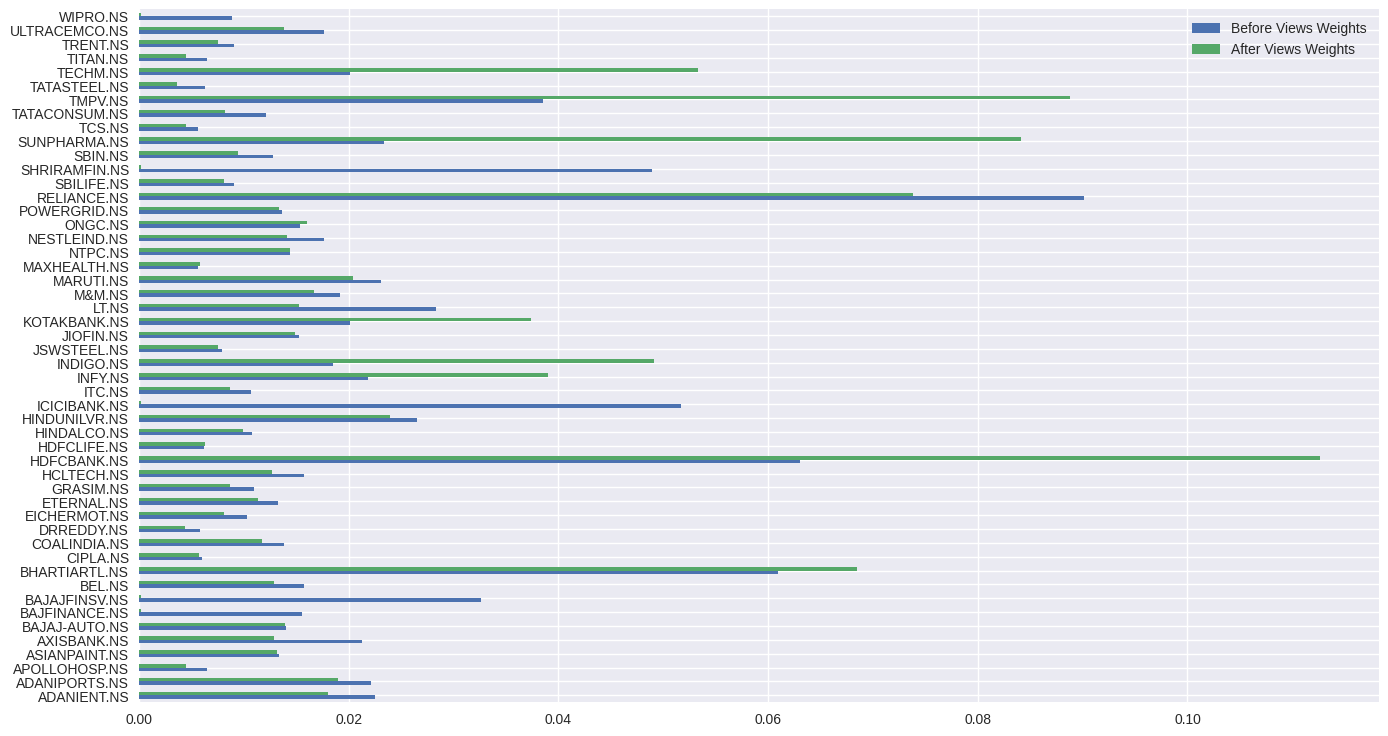

In [76]:
# Bar Plot - Before and After view weights
df = pd.DataFrame({'Before Views Weights': result_2.W, 'After Views Weights ': final_weights}, index = stocks_list)
ax = df.plot.barh()

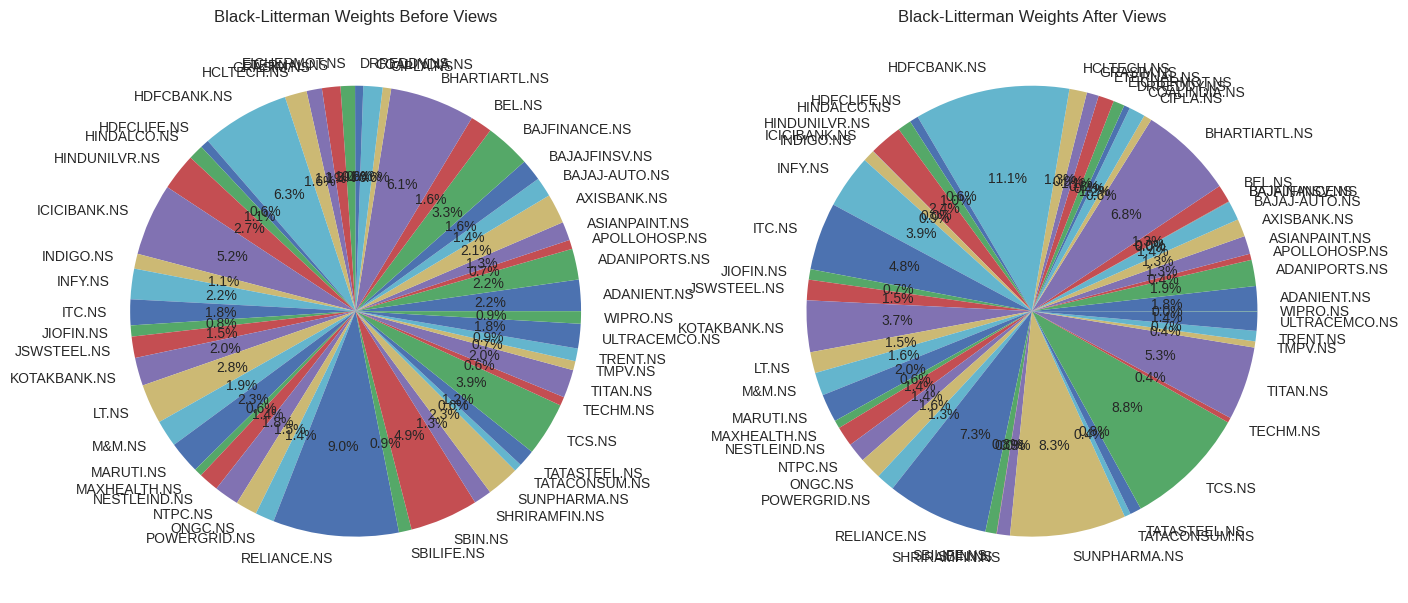

In [77]:
# Comparison b/w Black-Litterman Weights Before Views & Black-Litterman Weights after Views
labels = names
BL_weights = result_2.W
BL_views_weights = final_weights

fig, axs = plt.subplots(1, 2, figsize=(16, 8))

axs[0].pie(BL_weights, labels=labels, autopct='%1.1f%%')
axs[0].set_title('Black-Litterman Weights Before Views')

axs[1].pie(BL_views_weights, labels=labels, autopct='%1.1f%%')
axs[1].set_title('Black-Litterman Weights After Views')

plt.show()

This project demonstrates the implementation of the Black-Litterman portfolio optimization framework on the NIFTY 50 universe by integrating market equilibrium with subjective investor views. Historical price data and market capitalizations were retrieved automatically using Yahoo Finance, enabling a fully reproducible workflow without requiring manually maintained datasets.

The analysis first constructs a traditional Markowitz mean-variance portfolio using historical returns and covariances. It then performs reverse optimization to infer the market-implied equilibrium returns from capitalization-weighted market portfolios. These equilibrium returns are subsequently adjusted using the Black-Litterman framework by incorporating both relative and absolute investor views, producing a new set of posterior expected returns and an updated optimal portfolio allocation.

The comparison between the equilibrium portfolio and the adjusted Black-Litterman portfolio illustrates how incorporating investor views changes portfolio composition. For example, the adjusted portfolio allocates higher weights to stocks such as HDFC Bank, TCS, Sun Pharma, Titan, ITC, Infosys, and Kotak Mahindra Bank, reflecting the positive views introduced into the model. Conversely, allocations to stocks including ICICI Bank, SBI, Bajaj Finance, Bajaj Finserv, and Wipro decrease significantly where the investor views are comparatively less favorable.

Overall, the project highlights several important insights:

Historical-return optimization (Markowitz) is highly sensitive to estimation error in expected returns.
Reverse optimization produces equilibrium returns that are consistent with observed market-capitalization weights.
The Black-Litterman framework provides a systematic mechanism to combine market information with investor convictions while avoiding extreme portfolio allocations typically observed in pure mean-variance optimization.
Portfolio weights respond intuitively to changes in investor views, demonstrating the flexibility of the Black-Litterman approach for tactical asset allocation.

This implementation provides an end-to-end quantitative portfolio construction pipeline encompassing data acquisition, market equilibrium estimation, mean-variance optimization, Black-Litterman posterior estimation, and portfolio comparison, making it a practical foundation for further enhancements such as dynamic views, transaction cost modeling, portfolio constraints, and out-of-sample backtesting.